In [2]:
from pymatgen.core import Composition
import pandas as pd
import math
import numpy as np
# No warnings about setting value on copy of slice
pd.options.mode.chained_assignment = None

# Display up to 60 columns of a dataframe
pd.set_option('display.max_columns', 60)

# Matplotlib visualization
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Internal ipython tool for setting figure size
from IPython.core.pylabtools import figsize

# Seaborn for visualization
import seaborn as sns

from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

config = {
    "mathtext.fontset":'stix',
    "font.family":'serif',
    "font.serif": ['Times New Roman'],
    "font.size": 24,
    'axes.unicode_minus': False 
}
rcParams.update(config)
plt.rcParams['axes.unicode_minus'] = False  
large = 22; med = 26; small = 12
params = {'axes.titlesize': large,
          'legend.fontsize': med,
          'figure.figsize': (8, 6),
          'axes.labelsize': med,
          'axes.titlesize': med,
          'xtick.labelsize': med,
          'ytick.labelsize': med,
          'figure.titlesize': large}
plt.rcParams.update(params)
plt.rcParams['figure.dpi'] = 400 

In [3]:
#
def generate_candidate(i):
    """
    Generate candidate double perovskite formulas based on given cations.
    
    Parameters:
        i (int or float): Parameter nA used in the tolerance factor calculation.
    
    Returns:
        list of dict: A list of candidate structures, each as a dictionary containing 
                      formula and related structural/ionic parameters.
    """
    candidates = []    
    for A in A_cations:
        for B in B_cations:
            for C in C_cations:
                for X in X_cations: 
                    if A != B and A!=C and B!=C and A!=X and B!=X and C!=X:
                        a = 2
                        b = 1
                        c = 1
                        x = 6
                        candidate = ''.join([ A, str(a), B, C,X, str(x)])
                        Ra= ion_radii_a[A] 
                        Rb= ion_radii_b[B] 
                        Rc= ion_radii_c[C] 
                        Rx= ion_radii_x[X] 
                        nA = i
                        RB = (Rb + Rc) / 2
                        if RB == 0 or math.log(Ra / RB)==0:
                            continue
                        Tf = (Rx / RB) - nA * (nA - (Ra / RB) / math.log(Ra / RB))
                             
                        tmp_dict = {'formula': candidate,
                                    #'formula': Composition(candidate).reduced_formula,
                                    'A': A,  
                                    'B': B,  
                                    'C': C,  
                                    'X': X,
                                    'Ra': ion_radii_a[A], 
                                    'Rb': ion_radii_b[B], 
                                    'Rc': ion_radii_c[C], 
                                    'RB': (Rb + Rc) / 2,
                                    'Rx': ion_radii_x[X],
                                    'Tf': (Rx/RB) - nA* (nA-(Ra/RB)/math.log(Ra/RB)) }
                    #if Ra>RB and Tf < 4.18:
                        candidates.append(tmp_dict) 

    return candidates

In [4]:
import concurrent.futures
def generate_candidates_concurrently(i):
    all_candidates = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=128) as executor:
        # Create all possible combinations of a and b values
        futures = [executor.submit(generate_candidate,i)]
        for future in concurrent.futures.as_completed(futures):
            all_candidates.extend(future.result())
        result = pd.DataFrame(all_candidates)
    return result.drop_duplicates(subset=['formula'], keep='first').reset_index(drop=True)

In [5]:
#A⁺
A_cations = ['Li', 'Na', 'K', 'Rb','Ag','Cs','Tl']
#B⁺
B_cations = ['Li','Na','K','Cu','Rb','Ag','Cs', 'Au','Hg','Tl']
#B'³⁺
C_cations = ['B','N','Al','P','Sc','Ti','V','Cr','Mn','Fe','Co', 'Ni','Cu','Ga',
             'As','Y','Nb','Mo','Ru','Rh','Pd','Ag','In','Sb','Ta','Ir','Au','Tl','Bi',
              'La','Ce','Pr','Nd','Pm','Sm','Eu','Gd','Tb','Dy','Ho', 'Er','Tm', 'Yb','Lu', 'U']
X_cations = ['F', 'Cl', 'Br','I']
ion_radii_a = {
    'Li':1.159, 'Na':1.392, 'K':1.641, 'Rb':1.722, 'Ag':1.521, 'Cs':1.882, 'Tl':1.698 }
ion_radii_b = {
    'Li':0.756, 'Na':1.028, 'K':1.388, 'Cu':0.774, 'Rb':1.517, 'Ag':1.152 , 'Cs':1.673, 'Au':1.362 ,'Hg':1.37 ,'Tl':1.493, 'Fr':1.8}
ion_radii_c = { 
    'B':0.266, 'N':0.166, 'Al':0.537, 'P':0.444, 'Sc':0.741, 'Ti':0.673, 'V':0.636, 'Cr':0.618,'Mn':0.645, 'Fe':0.646, 'Co':0.612, 'Ni':0.601,'Cu':0.62, 'Ga':0.62,
    'As':0.583,'Y':0.899,'Nb':0.724,'Mo':0.691,'Ru':0.676,'Rh':0.672,'Pd':0.851,'Ag':0.757,'In':0.795,'Sb':0.861,'Ta':0.726,'Ir':0.687,'Au':0.842,'Tl':0.884,'Bi':1.03,
    'La':1.032,'Ce':1.01,'Pr':0.993,'Nd':0.98,'Pm':0.969,'Sm':0.958,'Eu':0.947,'Tb':0.924,'Gd':0.936,'Dy':0.912,'Ho':0.9, 'Er':0.889,'Tm':0.879, 'Yb':0.868,'Lu':0.857, 
    'Ac':1.11,'Pa':1.04,'U':1.024, 'Np':1.01,'Pu':1.0, 'Am':0.98,'Cm':0.97 }
ion_radii_x = {'F':1.331, 'Cl':1.806, 'Br': 1.955, 'I':2.194}

In [6]:
i = 1
group1 = generate_candidates_concurrently(i)
group1

,formula,A,B,C,X,Ra,Rb,Rc,RB,Rx,Tf
0,Li2NaBF6,Li,Na,B,F,1.159,1.028,0.266,0.6470,1.331,4.129996
1,Li2NaBCl6,Li,Na,B,Cl,1.159,1.028,0.266,0.6470,1.806,4.864153
2,Li2NaBBr6,Li,Na,B,Br,1.159,1.028,0.266,0.6470,1.955,5.094447
3,Li2NaBI6,Li,Na,B,I,1.159,1.028,0.266,0.6470,2.194,5.463844
4,Li2NaNF6,Li,Na,N,F,1.159,1.028,0.166,0.5970,1.331,4.155899
...,...,...,...,...,...,...,...,...,...,...,...
11155,Tl2HgLuI6,Tl,Hg,Lu,I,1.698,1.370,0.857,1.1135,2.194,4.584411
11156,Tl2HgUF6,Tl,Hg,U,F,1.698,1.370,1.024,1.1970,1.331,4.169194
11157,Tl2HgUCl6,Tl,Hg,U,Cl,1.698,1.370,1.024,1.1970,1.806,4.566020
11158,Tl2HgUBr6,Tl,Hg,U,Br,1.698,1.370,1.024,1.1970,1.955,4.690498


In [7]:
group1['number'] = 1
group1

,formula,A,B,C,X,Ra,Rb,Rc,RB,Rx,Tf,number
0,Li2NaBF6,Li,Na,B,F,1.159,1.028,0.266,0.6470,1.331,4.129996,1
1,Li2NaBCl6,Li,Na,B,Cl,1.159,1.028,0.266,0.6470,1.806,4.864153,1
2,Li2NaBBr6,Li,Na,B,Br,1.159,1.028,0.266,0.6470,1.955,5.094447,1
3,Li2NaBI6,Li,Na,B,I,1.159,1.028,0.266,0.6470,2.194,5.463844,1
4,Li2NaNF6,Li,Na,N,F,1.159,1.028,0.166,0.5970,1.331,4.155899,1
...,...,...,...,...,...,...,...,...,...,...,...,...
11155,Tl2HgLuI6,Tl,Hg,Lu,I,1.698,1.370,0.857,1.1135,2.194,4.584411,1
11156,Tl2HgUF6,Tl,Hg,U,F,1.698,1.370,1.024,1.1970,1.331,4.169194,1
11157,Tl2HgUCl6,Tl,Hg,U,Cl,1.698,1.370,1.024,1.1970,1.806,4.566020,1
11158,Tl2HgUBr6,Tl,Hg,U,Br,1.698,1.370,1.024,1.1970,1.955,4.690498,1


In [8]:
import math

def generate_unique_candidates(i):
    candidates = []
    generated_formulas = set()

    for A in A_cations:
        for B in B_cations:
            for C in C_cations:
                for X in X_cations: 
                    if A != B and A != C and B != C and A != X and B != X and C != X:
                        a = 2
                        b = 1
                        c = 1
                        x = 6
                        candidate = f"{A}{a}{B}{C}{X}{x}"
                        sorted_candidate = f"{A}{a}{sorted([B, C])}{X}{x}"

                        if sorted_candidate in generated_formulas:
                            continue

                        Ra = ion_radii_a[A]
                        Rb = ion_radii_b[B]
                        Rc = ion_radii_c[C]
                        Rx = ion_radii_x[X]
                        nA = i
                        RB = (Rb + Rc) / 2
                        if RB == 0 or math.isclose(math.log(Ra / RB), 0):
                            continue
                        Tf = (Rx / RB) - nA * (nA - (Ra / RB) / math.log(Ra / RB))

                        tmp_dict = {
                            'formula': candidate,
                            'A': A,
                            'B': B,
                            'C': C,
                            'X': X,
                            'Ra': Ra,
                            'Rb': Rb,
                            'Rc': Rc,
                            'RB': RB,
                            'Rx': Rx,
                            'Tf': Tf
                        }

                        candidates.append(tmp_dict)
                        generated_formulas.add(candidate)
                        generated_formulas.add(sorted_candidate)

    return candidates

In [9]:
import concurrent.futures
def generate_candidates_concurrently_re(i):
    all_candidates = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=128) as executor:
        # Create all possible combinations of a and b values
        futures = [executor.submit(generate_unique_candidates,i)]
        for future in concurrent.futures.as_completed(futures):
            all_candidates.extend(future.result())
        result = pd.DataFrame(all_candidates)
    return result.drop_duplicates(subset=['formula'], keep='first').reset_index(drop=True)

In [10]:
#A⁺
A_cations = ['Li', 'Na', 'K', 'Rb','Ag','Cs','Tl']
#B²⁺
B_cations = ['Be','Mg','Ca','Sc','Ti','V','Cr','Mn','Fe','Co', 'Ni','Cu','Zn','Ge',
             'Sr','Y','Nb','Pd','Ag','Cd','In','Sn','Ba','Pt','Hg','Pb',
             'La','Ce','Pr','Sm','Eu','Dy','Tm','Yb']
#B'²⁺
C_cations = ['Be','Mg','Ca','Sc','Ti','V','Cr','Mn','Fe','Co', 'Ni','Cu','Zn','Ge',
             'Sr','Y','Nb','Pd','Ag','Cd','In','Sn','Ba','Pt','Hg','Pb',
             'La','Ce','Pr','Sm','Eu','Dy','Tm','Yb']

ion_radii_a = { 'Li':1.159, 'Na':1.392, 'K':1.641, 'Rb':1.722, 'Ag':1.521, 'Cs':1.882, 'Tl':1.698 }

ion_radii_b = {
                'Be':0.449,'Mg':0.724,'Ca':0.999,'Sc':0.936,'Ti':0.856,'V':0.793,'Cr':0.801,'Mn':0.828,'Fe':0.784,'Co':0.742, 'Ni':0.695,'Cu':0.726,'Zn':0.743,'Ge':0.73,
             'Sr':1.179,'Y':1.113,'Nb':0.927,'Pd':0.866,'Ag':0.936,'Cd':0.951,'In':0.989,'Sn':1.02,'Ba':1.34,'Pt':0.984,'Hg':1.03,'Pb':1.18,
            'La':1.31,'Ce':1.287,'Pr':1.26,'Sm':1.19,'Eu':1.16,'Dy':1.07,
               'Tm':1.03,'Yb':1.02,'Np':1.10  }
ion_radii_c = {
                'Be':0.449,'Mg':0.724,'Ca':0.999,'Sc':0.936,'Ti':0.856,'V':0.793,'Cr':0.801,'Mn':0.828,'Fe':0.784,'Co':0.742, 'Ni':0.695,'Cu':0.726,'Zn':0.743,'Ge':0.73,
             'Sr':1.179,'Y':1.113,'Nb':0.927,'Pd':0.866,'Ag':0.936,'Cd':0.951,'In':0.989,'Sn':1.02,'Ba':1.34,'Pt':0.984,'Hg':1.03,'Pb':1.18,
            'La':1.31,'Ce':1.287,'Pr':1.26,'Sm':1.19,'Eu':1.16,'Dy':1.07,
               'Tm':1.03,'Yb':1.02,'Np':1.10  }

ion_radii_x = {'F':1.331, 'Cl':1.806, 'Br': 1.955, 'I':2.194}

In [11]:
group2 = generate_candidates_concurrently_re(i)
group2

,formula,A,B,C,X,Ra,Rb,Rc,RB,Rx,Tf
0,Li2BeMgF6,Li,Be,Mg,F,1.159,0.449,0.724,0.5865,1.331,4.170603
1,Li2BeMgCl6,Li,Be,Mg,Cl,1.159,0.449,0.724,0.5865,1.806,4.980492
2,Li2BeMgBr6,Li,Be,Mg,Br,1.159,0.449,0.724,0.5865,1.955,5.234542
3,Li2BeMgI6,Li,Be,Mg,I,1.159,0.449,0.724,0.5865,2.194,5.642044
4,Li2BeCaF6,Li,Be,Ca,F,1.159,0.449,0.999,0.7240,1.331,4.240642
...,...,...,...,...,...,...,...,...,...,...,...
15571,Tl2DyYbI6,Tl,Dy,Yb,I,1.698,1.070,1.020,1.0450,2.194,4.446794
15572,Tl2TmYbF6,Tl,Tm,Yb,F,1.698,1.030,1.020,1.0250,1.331,3.580473
15573,Tl2TmYbCl6,Tl,Tm,Yb,Cl,1.698,1.030,1.020,1.0250,1.806,4.043888
15574,Tl2TmYbBr6,Tl,Tm,Yb,Br,1.698,1.030,1.020,1.0250,1.955,4.189254


In [12]:
group2['number'] = 2
group2

,formula,A,B,C,X,Ra,Rb,Rc,RB,Rx,Tf,number
0,Li2BeMgF6,Li,Be,Mg,F,1.159,0.449,0.724,0.5865,1.331,4.170603,2
1,Li2BeMgCl6,Li,Be,Mg,Cl,1.159,0.449,0.724,0.5865,1.806,4.980492,2
2,Li2BeMgBr6,Li,Be,Mg,Br,1.159,0.449,0.724,0.5865,1.955,5.234542,2
3,Li2BeMgI6,Li,Be,Mg,I,1.159,0.449,0.724,0.5865,2.194,5.642044,2
4,Li2BeCaF6,Li,Be,Ca,F,1.159,0.449,0.999,0.7240,1.331,4.240642,2
...,...,...,...,...,...,...,...,...,...,...,...,...
15571,Tl2DyYbI6,Tl,Dy,Yb,I,1.698,1.070,1.020,1.0450,2.194,4.446794,2
15572,Tl2TmYbF6,Tl,Tm,Yb,F,1.698,1.030,1.020,1.0250,1.331,3.580473,2
15573,Tl2TmYbCl6,Tl,Tm,Yb,Cl,1.698,1.030,1.020,1.0250,1.806,4.043888,2
15574,Tl2TmYbBr6,Tl,Tm,Yb,Br,1.698,1.030,1.020,1.0250,1.955,4.189254,2


In [13]:
#A²⁺
A_cations = ['Ca','Mn','Fe' ,'Cu','Sr','Cd','Ba','Hg','Pb', 'La','Pr','Nd','Eu','Tm','Yb']
#B⁺
B_cations = ['Li','Na','K','Cu','Rb','Ag','Cs', 'Au','Hg','Tl']
#B'⁺
C_cations = ['Li','Na','K','Cu','Rb','Ag','Cs', 'Au','Hg','Tl']

ion_radii_a = { 'Ca':1.336,'Mn': 1.205, 'Fe':1.186,'Cu':1.151,'Sr':1.444,'Cd':1.314,'Ba':1.61,'Hg':1.349,'Pb':1.492,
               'Ra':1.699,'La':1.581,'Pr':1.527,'Nd':1.501,'Eu':1.437,'Tm':1.352,'Yb':1.342}
ion_radii_b = {
     'Li':0.756, 'Na':1.028, 'K':1.388, 'Cu':0.774, 'Rb':1.517, 'Ag':1.552 , 'Cs':1.673, 'Au':1.362 ,'Hg':1.370 ,'Tl':1.493, 'Fr':1.798}
ion_radii_c = {
    'Li':0.756, 'Na':1.028, 'K':1.388, 'Cu':0.774, 'Rb':1.517, 'Ag':1.552 , 'Cs':1.673, 'Au':1.362 ,'Hg':1.370 ,'Tl':1.493, 'Fr':1.798}
ion_radii_x = {'F':1.331, 'Cl':1.806, 'Br': 1.955, 'I':2.194}

In [14]:
group3 = generate_candidates_concurrently_re(2)
group3

,formula,A,B,C,X,Ra,Rb,Rc,RB,Rx,Tf
0,Ca2LiNaF6,Ca,Li,Na,F,1.336,0.756,1.028,0.8920,1.331,4.907360
1,Ca2LiNaCl6,Ca,Li,Na,Cl,1.336,0.756,1.028,0.8920,1.806,5.439871
2,Ca2LiNaBr6,Ca,Li,Na,Br,1.336,0.756,1.028,0.8920,1.955,5.606912
3,Ca2LiNaI6,Ca,Li,Na,I,1.336,0.756,1.028,0.8920,2.194,5.874849
4,Ca2LiKF6,Ca,Li,K,F,1.336,0.756,1.388,1.0720,1.331,8.563394
...,...,...,...,...,...,...,...,...,...,...,...
2623,Yb2AuTlI6,Yb,Au,Tl,I,1.342,1.362,1.493,1.4275,2.194,-32.905078
2624,Yb2HgTlF6,Yb,Hg,Tl,F,1.342,1.370,1.493,1.4315,1.331,-32.111468
2625,Yb2HgTlCl6,Yb,Hg,Tl,Cl,1.342,1.370,1.493,1.4315,1.806,-31.779648
2626,Yb2HgTlBr6,Yb,Hg,Tl,Br,1.342,1.370,1.493,1.4315,1.955,-31.675561


In [15]:
group3['number'] = 3
group3

,formula,A,B,C,X,Ra,Rb,Rc,RB,Rx,Tf,number
0,Ca2LiNaF6,Ca,Li,Na,F,1.336,0.756,1.028,0.8920,1.331,4.907360,3
1,Ca2LiNaCl6,Ca,Li,Na,Cl,1.336,0.756,1.028,0.8920,1.806,5.439871,3
2,Ca2LiNaBr6,Ca,Li,Na,Br,1.336,0.756,1.028,0.8920,1.955,5.606912,3
3,Ca2LiNaI6,Ca,Li,Na,I,1.336,0.756,1.028,0.8920,2.194,5.874849,3
4,Ca2LiKF6,Ca,Li,K,F,1.336,0.756,1.388,1.0720,1.331,8.563394,3
...,...,...,...,...,...,...,...,...,...,...,...,...
2623,Yb2AuTlI6,Yb,Au,Tl,I,1.342,1.362,1.493,1.4275,2.194,-32.905078,3
2624,Yb2HgTlF6,Yb,Hg,Tl,F,1.342,1.370,1.493,1.4315,1.331,-32.111468,3
2625,Yb2HgTlCl6,Yb,Hg,Tl,Cl,1.342,1.370,1.493,1.4315,1.806,-31.779648,3
2626,Yb2HgTlBr6,Yb,Hg,Tl,Br,1.342,1.370,1.493,1.4315,1.955,-31.675561,3


In [44]:
#All the final generated candidates
group = pd.concat([group1, group2, group3],axis = 0).reset_index(drop=True)
group

,formula,A,B,C,X,Ra,Rb,Rc,RB,Rx,Tf,number
0,Li2NaBF6,Li,Na,B,F,1.159,1.028,0.266,0.6470,1.331,4.129996,1
1,Li2NaBCl6,Li,Na,B,Cl,1.159,1.028,0.266,0.6470,1.806,4.864153,1
2,Li2NaBBr6,Li,Na,B,Br,1.159,1.028,0.266,0.6470,1.955,5.094447,1
3,Li2NaBI6,Li,Na,B,I,1.159,1.028,0.266,0.6470,2.194,5.463844,1
4,Li2NaNF6,Li,Na,N,F,1.159,1.028,0.166,0.5970,1.331,4.155899,1
...,...,...,...,...,...,...,...,...,...,...,...,...
29359,Yb2AuTlI6,Yb,Au,Tl,I,1.342,1.362,1.493,1.4275,2.194,-32.905078,3
29360,Yb2HgTlF6,Yb,Hg,Tl,F,1.342,1.370,1.493,1.4315,1.331,-32.111468,3
29361,Yb2HgTlCl6,Yb,Hg,Tl,Cl,1.342,1.370,1.493,1.4315,1.806,-31.779648,3
29362,Yb2HgTlBr6,Yb,Hg,Tl,Br,1.342,1.370,1.493,1.4315,1.955,-31.675561,3


In [16]:
group.to_csv('./data/data.csv',index = False)

In [45]:
#Complementary verification: compare according to the chemical formula and the MP database, and retain the candidate materials existing in the MP database.
matched_all = pd.merge(group, mp, left_on='formula',right_on='formula_pretty', how='inner')
matched_all

,formula_x,A,B,C,X,Ra,Rb,Rc,RB,Rx,Tf,number,material_id,formula_pretty,formation_energy_per_atom,energy_above_hull,is_gap_direct,band_gap,spacegroup_number,structure,formula_y,composition,is_GGA_U
0,Li2CuNiF6,Li,Cu,Ni,F,1.159,0.774,0.601,0.6875,1.331,4.163985,1,mp-1111560,Li2CuNiF6,-2.248985,0.243059,False,0.0000,225,Full Formula (Li2 Cu1 Ni1 F6)\nReduced Formula...,Li2CuNiF6,Li2 Cu1 Ni1 F6,1
1,Li2CuAsF6,Li,Cu,As,F,1.159,0.774,0.583,0.6785,1.331,4.151985,1,mp-1111360,Li2CuAsF6,-2.035597,0.405407,False,0.6339,225,Full Formula (Li2 Cu1 As1 F6)\nReduced Formula...,Li2CuAsF6,Li2 Cu1 As1 F6,0
2,Li2CuMoF6,Li,Cu,Mo,F,1.159,0.774,0.691,0.7325,1.331,4.265369,1,mp-1111143,Li2CuMoF6,-2.224578,0.415521,False,0.0000,225,Full Formula (Li2 Cu1 Mo1 F6)\nReduced Formula...,Li2CuMoF6,Li2 Cu1 Mo1 F6,1
3,Li2CuSbF6,Li,Cu,Sb,F,1.159,0.774,0.861,0.8175,1.331,4.689697,1,mp-1111097,Li2CuSbF6,-2.175725,0.461284,False,0.3670,225,Full Formula (Li2 Cu1 Sb1 F6)\nReduced Formula...,Li2CuSbF6,Li2 Cu1 Sb1 F6,0
4,Li2CuSbCl6,Li,Cu,Sb,Cl,1.159,0.774,0.861,0.8175,1.806,5.270737,1,mp-1111120,Li2CuSbCl6,-0.999948,0.288516,False,0.6312,225,Full Formula (Li2 Cu1 Sb1 Cl6)\nReduced Formul...,Li2CuSbCl6,Li2 Cu1 Sb1 Cl6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1162,Cs2NbAgF6,Cs,Nb,Ag,F,1.882,0.927,0.936,0.9315,1.331,3.301641,2,mp-1112950,Cs2NbAgF6,-2.592607,0.282992,False,0.0000,225,Full Formula (Cs2 Nb1 Ag1 F6)\nReduced Formula...,Cs2NbAgF6,Cs2 Nb1 Ag1 F6,0
1163,Cs2InHgF6,Cs,In,Hg,F,1.882,0.989,1.030,1.0095,1.331,3.311490,2,mp-1113143,Cs2InHgF6,-2.572872,0.062973,False,0.0000,225,Full Formula (Cs2 In1 Hg1 F6)\nReduced Formula...,Cs2InHgF6,Cs2 In1 Hg1 F6,0
1164,Cs2InHgCl6,Cs,In,Hg,Cl,1.882,0.989,1.030,1.0095,1.806,3.782020,2,mp-1112904,Cs2InHgCl6,-1.697084,0.055424,False,0.0000,225,Full Formula (Cs2 In1 Hg1 Cl6)\nReduced Formul...,Cs2InHgCl6,Cs2 In1 Hg1 Cl6,0
1165,Cs2InHgBr6,Cs,In,Hg,Br,1.882,0.989,1.030,1.0095,1.955,3.929618,2,mp-1113300,Cs2InHgBr6,-1.507350,0.002657,False,0.0000,225,Full Formula (Cs2 In1 Hg1 Br6)\nReduced Formul...,Cs2InHgBr6,Cs2 In1 Hg1 Br6,0


In [48]:
#Tf is unstable, but energy_above_hull is stable.
Tf0 = matched_all[~((matched_all['Ra'] > matched_all['RB']) & (matched_all['Tf'] < 4.18))]
Tf0_eh1 = Tf0[Tf0['energy_above_hull'] <= 0.02]
Tf0_eh1

,formula_x,A,B,C,X,Ra,Rb,Rc,RB,Rx,Tf,number,material_id,formula_pretty,formation_energy_per_atom,energy_above_hull,is_gap_direct,band_gap,spacegroup_number,structure,formula_y,composition,is_GGA_U
8,Na2LiNF6,Na,Li,N,F,1.392,0.756,0.166,0.4610,1.331,4.619557,1,mp-989504,Na2LiNF6,-1.812514,0.000000,False,2.4767,225,Full Formula (Na2 Li1 N1 F6)\nReduced Formula:...,Na2LiNF6,Na2 Li1 N1 F6,0
97,K2LiScCl6,K,Li,Sc,Cl,1.641,0.756,0.741,0.7485,1.806,4.205708,1,mp-1111932,K2LiScCl6,-2.237860,0.008983,True,3.7414,225,Full Formula (K2 Li1 Sc1 Cl6)\nReduced Formula...,K2LiScCl6,K2 Li1 Sc1 Cl6,0
163,K2NaScBr6,K,Na,Sc,Br,1.641,1.028,0.741,0.8845,1.955,4.212181,1,mp-1111649,K2NaScBr6,-2.062478,0.000000,False,3.0952,225,Full Formula (K2 Na1 Sc1 Br6)\nReduced Formula...,K2NaScBr6,K2 Na1 Sc1 Br6,0
334,K2AgSbBr6,K,Ag,Sb,Br,1.641,1.152,0.861,1.0065,1.955,4.277712,1,mp-1110912,K2AgSbBr6,-1.373285,0.019743,False,1.1248,225,Full Formula (K2 Ag1 Sb1 Br6)\nReduced Formula...,K2AgSbBr6,K2 Ag1 Sb1 Br6,0
341,K2AgBiCl6,K,Ag,Bi,Cl,1.641,1.152,1.030,1.0910,1.806,4.340036,1,mp-1110920,K2AgBiCl6,-1.627033,0.000000,False,2.0583,225,Full Formula (K2 Ag1 Bi1 Cl6)\nReduced Formula...,K2AgBiCl6,K2 Ag1 Bi1 Cl6,0
383,K2TlAgCl6,K,Tl,Ag,Cl,1.641,1.493,0.757,1.1250,1.806,4.469118,1,mp-1112081,K2TlAgCl6,-1.507778,0.013922,False,0.0000,225,Full Formula (K2 Tl1 Ag1 Cl6)\nReduced Formula...,K2TlAgCl6,K2 Tl1 Ag1 Cl6,0
412,Rb2LiYBr6,Rb,Li,Y,Br,1.722,0.756,0.899,0.8275,1.955,4.202159,1,mp-1110706,Rb2LiYBr6,-2.162580,0.000000,True,4.0420,225,Full Formula (Rb2 Li1 Y1 Br6)\nReduced Formula...,Rb2LiYBr6,Rb2 Li1 Y1 Br6,0
437,Rb2LiTlBr6,Rb,Li,Tl,Br,1.722,0.756,0.884,0.8200,1.955,4.214574,1,mp-1114027,Rb2LiTlBr6,-1.576283,0.000000,True,0.5529,225,Full Formula (Rb2 Li1 Tl1 Br6)\nReduced Formul...,Rb2LiTlBr6,Rb2 Li1 Tl1 Br6,0
460,Rb2LiDyBr6,Rb,Li,Dy,Br,1.722,0.756,0.912,0.8340,1.955,4.192021,1,mp-567628,Rb2LiDyBr6,-2.165442,0.000000,True,4.1439,225,Full Formula (Rb2 Li1 Dy1 Br6)\nReduced Formul...,Rb2LiDyBr6,Rb2 Li1 Dy1 Br6,0
470,Rb2NaScI6,Rb,Na,Sc,I,1.722,1.028,0.741,0.8845,2.194,4.402753,1,mp-1114119,Rb2NaScI6,-1.591977,0.000000,False,2.2079,225,Full Formula (Rb2 Na1 Sc1 I6)\nReduced Formula...,Rb2NaScI6,Rb2 Na1 Sc1 I6,0


In [50]:
len(Tf0_eh1)

35

In [51]:
#Tf is stable, energy_above_hull is stable.
Tf1 = matched_all[(matched_all['Ra'] > matched_all['RB']) & (matched_all['Tf'] < 4.18)]
Tf1_eh1 = Tf1[Tf1['energy_above_hull'] <= 0.02]
Tf1_eh1

,formula_x,A,B,C,X,Ra,Rb,Rc,RB,Rx,Tf,number,material_id,formula_pretty,formation_energy_per_atom,energy_above_hull,is_gap_direct,band_gap,spacegroup_number,structure,formula_y,composition,is_GGA_U
17,Na2LiGaF6,Na,Li,Ga,F,1.392,0.756,0.620,0.6880,1.331,3.805649,1,mp-1114242,Na2LiGaF6,-3.016822,0.019079,True,5.7453,225,Full Formula (Na2 Li1 Ga1 F6)\nReduced Formula...,Na2LiGaF6,Na2 Li1 Ga1 F6,0
95,K2LiAlF6,K,Li,Al,F,1.641,0.756,0.537,0.6465,1.331,3.783755,1,mp-9839,K2LiAlF6,-3.464196,0.001649,True,7.4418,225,Full Formula (K2 Li1 Al1 F6)\nReduced Formula:...,K2LiAlF6,K2 Li1 Al1 F6,0
96,K2LiScF6,K,Li,Sc,F,1.641,0.756,0.741,0.7485,1.331,3.571106,1,mp-1111110,K2LiScF6,-3.599047,0.000000,True,6.7733,225,Full Formula (K2 Li1 Sc1 F6)\nReduced Formula:...,K2LiScF6,K2 Li1 Sc1 F6,0
98,K2LiTiF6,K,Li,Ti,F,1.641,0.756,0.673,0.7145,1.331,3.625044,1,mp-1111107,K2LiTiF6,-3.339027,0.003204,False,0.0000,225,Full Formula (K2 Li1 Ti1 F6)\nReduced Formula:...,K2LiTiF6,K2 Li1 Ti1 F6,0
100,K2LiCrF6,K,Li,Cr,F,1.641,0.756,0.618,0.6870,1.331,3.680688,1,mp-1111927,K2LiCrF6,-3.145196,0.000000,False,4.1644,225,Full Formula (K2 Li1 Cr1 F6)\nReduced Formula:...,K2LiCrF6,K2 Li1 Cr1 F6,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1154,Cs2YInF6,Cs,Y,In,F,1.882,1.113,0.989,1.0510,1.331,3.340044,2,mp-1113062,Cs2YInF6,-3.324185,0.018044,False,4.0503,225,Full Formula (Cs2 Y1 In1 F6)\nReduced Formula:...,Cs2YInF6,Cs2 Y1 In1 F6,0
1155,Cs2YInCl6,Cs,Y,In,Cl,1.882,1.113,0.989,1.0510,1.806,3.791994,2,mp-1112628,Cs2YInCl6,-2.136585,0.009258,True,3.4960,225,Full Formula (Cs2 Y1 In1 Cl6)\nReduced Formula...,Cs2YInCl6,Cs2 Y1 In1 Cl6,0
1156,Cs2YInBr6,Cs,Y,In,Br,1.882,1.113,0.989,1.0510,1.955,3.933764,2,mp-1113063,Cs2YInBr6,-2.008738,0.006739,True,2.9636,225,Full Formula (Cs2 Y1 In1 Br6)\nReduced Formula...,Cs2YInBr6,Cs2 Y1 In1 Br6,0
1157,Cs2YInI6,Cs,Y,In,I,1.882,1.113,0.989,1.0510,2.194,4.161166,2,mp-1112795,Cs2YInI6,-1.537834,0.000932,False,0.0509,225,Full Formula (Cs2 Y1 In1 I6)\nReduced Formula:...,Cs2YInI6,Cs2 Y1 In1 I6,0


In [53]:
#Tf is stable, but energy_above_hull is unstable.
Tf1 = matched_all[(matched_all['Ra'] > matched_all['RB']) & (matched_all['Tf'] < 4.18)]
Tf1_eh0 = Tf1[Tf1['energy_above_hull'] > 0.02]
Tf1_eh0

,formula_x,A,B,C,X,Ra,Rb,Rc,RB,Rx,Tf,number,material_id,formula_pretty,formation_energy_per_atom,energy_above_hull,is_gap_direct,band_gap,spacegroup_number,structure,formula_y,composition,is_GGA_U
0,Li2CuNiF6,Li,Cu,Ni,F,1.159,0.774,0.601,0.6875,1.331,4.163985,1,mp-1111560,Li2CuNiF6,-2.248985,0.243059,False,0.0000,225,Full Formula (Li2 Cu1 Ni1 F6)\nReduced Formula...,Li2CuNiF6,Li2 Cu1 Ni1 F6,1
1,Li2CuAsF6,Li,Cu,As,F,1.159,0.774,0.583,0.6785,1.331,4.151985,1,mp-1111360,Li2CuAsF6,-2.035597,0.405407,False,0.6339,225,Full Formula (Li2 Cu1 As1 F6)\nReduced Formula...,Li2CuAsF6,Li2 Cu1 As1 F6,0
9,Na2LiAlF6,Na,Li,Al,F,1.392,0.756,0.537,0.6465,1.331,3.866270,1,mp-1111056,Na2LiAlF6,-3.408228,0.033782,True,6.5460,225,Full Formula (Na2 Li1 Al1 F6)\nReduced Formula...,Na2LiAlF6,Na2 Li1 Al1 F6,0
10,Na2LiScF6,Na,Li,Sc,F,1.392,0.756,0.741,0.7485,1.331,3.775713,1,mp-1113900,Na2LiScF6,-3.484104,0.078753,True,6.0598,225,Full Formula (Na2 Li1 Sc1 F6)\nReduced Formula...,Na2LiScF6,Na2 Li1 Sc1 F6,0
12,Na2LiTiF6,Na,Li,Ti,F,1.392,0.756,0.673,0.7145,1.331,3.784081,1,mp-1113901,Na2LiTiF6,-3.233286,0.067137,False,0.0000,225,Full Formula (Na2 Li1 Ti1 F6)\nReduced Formula...,Na2LiTiF6,Na2 Li1 Ti1 F6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1161,Cs2YHgI6,Cs,Y,Hg,I,1.882,1.113,1.030,1.0715,2.194,4.165816,2,mp-1112895,Cs2YHgI6,-1.432473,0.071347,False,0.0000,225,Full Formula (Cs2 Y1 Hg1 I6)\nReduced Formula:...,Cs2YHgI6,Cs2 Y1 Hg1 I6,0
1162,Cs2NbAgF6,Cs,Nb,Ag,F,1.882,0.927,0.936,0.9315,1.331,3.301641,2,mp-1112950,Cs2NbAgF6,-2.592607,0.282992,False,0.0000,225,Full Formula (Cs2 Nb1 Ag1 F6)\nReduced Formula...,Cs2NbAgF6,Cs2 Nb1 Ag1 F6,0
1163,Cs2InHgF6,Cs,In,Hg,F,1.882,0.989,1.030,1.0095,1.331,3.311490,2,mp-1113143,Cs2InHgF6,-2.572872,0.062973,False,0.0000,225,Full Formula (Cs2 In1 Hg1 F6)\nReduced Formula...,Cs2InHgF6,Cs2 In1 Hg1 F6,0
1164,Cs2InHgCl6,Cs,In,Hg,Cl,1.882,0.989,1.030,1.0095,1.806,3.782020,2,mp-1112904,Cs2InHgCl6,-1.697084,0.055424,False,0.0000,225,Full Formula (Cs2 In1 Hg1 Cl6)\nReduced Formul...,Cs2InHgCl6,Cs2 In1 Hg1 Cl6,0


In [54]:
#Tf is unstable, energy_above_hull is unstable.
Tf0 = matched_all[~((matched_all['Ra'] > matched_all['RB']) & (matched_all['Tf'] < 4.18))]
Tf0_eh0 = Tf0[Tf0['energy_above_hull'] > 0.02]
Tf0_eh0

,formula_x,A,B,C,X,Ra,Rb,Rc,RB,Rx,Tf,number,material_id,formula_pretty,formation_energy_per_atom,energy_above_hull,is_gap_direct,band_gap,spacegroup_number,structure,formula_y,composition,is_GGA_U
2,Li2CuMoF6,Li,Cu,Mo,F,1.159,0.774,0.691,0.7325,1.331,4.265369,1,mp-1111143,Li2CuMoF6,-2.224578,0.415521,False,0.0000,225,Full Formula (Li2 Cu1 Mo1 F6)\nReduced Formula...,Li2CuMoF6,Li2 Cu1 Mo1 F6,1
3,Li2CuSbF6,Li,Cu,Sb,F,1.159,0.774,0.861,0.8175,1.331,4.689697,1,mp-1111097,Li2CuSbF6,-2.175725,0.461284,False,0.3670,225,Full Formula (Li2 Cu1 Sb1 F6)\nReduced Formula...,Li2CuSbF6,Li2 Cu1 Sb1 F6,0
4,Li2CuSbCl6,Li,Cu,Sb,Cl,1.159,0.774,0.861,0.8175,1.806,5.270737,1,mp-1111120,Li2CuSbCl6,-0.999948,0.288516,False,0.6312,225,Full Formula (Li2 Cu1 Sb1 Cl6)\nReduced Formul...,Li2CuSbCl6,Li2 Cu1 Sb1 Cl6,0
5,Li2CuIrF6,Li,Cu,Ir,F,1.159,0.774,0.687,0.7305,1.331,4.259303,1,mp-1111113,Li2CuIrF6,-1.840185,0.377505,False,0.7390,225,Full Formula (Li2 Cu1 Ir1 F6)\nReduced Formula...,Li2CuIrF6,Li2 Cu1 Ir1 F6,0
6,Li2CuAuF6,Li,Cu,Au,F,1.159,0.774,0.842,0.8080,1.331,4.623446,1,mp-1111359,Li2CuAuF6,-1.850606,0.345807,False,0.0000,225,Full Formula (Li2 Cu1 Au1 F6)\nReduced Formula...,Li2CuAuF6,Li2 Cu1 Au1 F6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1122,Rb2YHgBr6,Rb,Y,Hg,Br,1.722,1.113,1.030,1.0715,1.955,4.211986,2,mp-1114137,Rb2YHgBr6,-1.828069,0.093685,False,0.0000,225,Full Formula (Rb2 Y1 Hg1 Br6)\nReduced Formula...,Rb2YHgBr6,Rb2 Y1 Hg1 Br6,0
1123,Rb2YHgI6,Rb,Y,Hg,I,1.722,1.113,1.030,1.0715,2.194,4.435037,2,mp-1114193,Rb2YHgI6,-1.377484,0.104343,False,0.0000,225,Full Formula (Rb2 Y1 Hg1 I6)\nReduced Formula:...,Rb2YHgI6,Rb2 Y1 Hg1 I6,0
1129,Rb2InHgI6,Rb,In,Hg,I,1.722,0.989,1.030,1.0095,2.194,4.367539,2,mp-1113551,Rb2InHgI6,-1.075135,0.068496,False,0.0000,225,Full Formula (Rb2 In1 Hg1 I6)\nReduced Formula...,Rb2InHgI6,Rb2 In1 Hg1 I6,0
1136,Cs2ScAgI6,Cs,Sc,Ag,I,1.882,0.936,0.936,0.9360,2.194,4.222695,2,mp-1112938,Cs2ScAgI6,-1.419224,0.042143,False,2.0571,225,Full Formula (Cs2 Sc1 Ag1 I6)\nReduced Formula...,Cs2ScAgI6,Cs2 Sc1 Ag1 I6,0


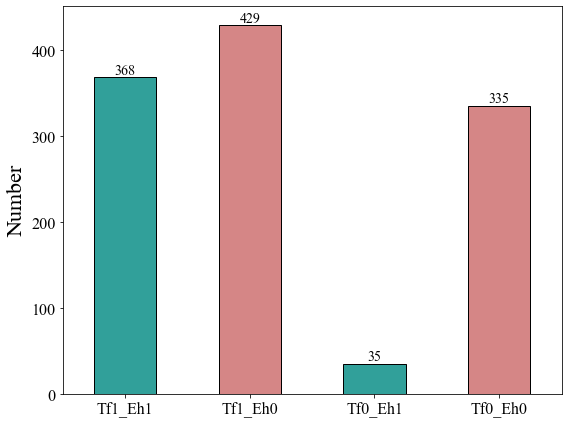

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

y_counts = [ len(Tf1_eh1), len(Tf1_eh0), len(Tf0_eh1), len(Tf0_eh0)]
labels   = ['Tf1_Eh1', 'Tf1_Eh0', 'Tf0_Eh1', 'Tf0_Eh0']
y_series = pd.Series(y_counts, index=labels)

ax = y_series.plot(
    kind='bar',
    color=['#31A09A', '#D58686', '#31A09A', '#D58686'],  # 4 个柱子需要 4 个颜色
    edgecolor='black',
    figsize=(8, 6)
)

plt.ylabel('Number', fontsize=22)
plt.xticks(ticks=range(4), labels=labels, rotation=0, fontsize=16)
plt.yticks(fontsize=16)
#plt.title('Distribution of Samples', fontsize=22)

for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom', fontsize=14
    )

plt.tight_layout()
plt.savefig('./picture/distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# 新容忍因子筛选

In [17]:
group = group[(group['Ra'] > group['RB']) & (group['Tf'] < 4.18)]
group

,formula,A,B,C,X,Ra,Rb,Rc,RB,Rx,Tf,number
0,Li2NaBF6,Li,Na,B,F,1.159,1.028,0.266,0.6470,1.331,4.129996,1
4,Li2NaNF6,Li,Na,N,F,1.159,1.028,0.166,0.5970,1.331,4.155899,1
368,Li2CuAlF6,Li,Cu,Al,F,1.159,0.774,0.537,0.6555,1.331,4.132934,1
372,Li2CuPF6,Li,Cu,P,F,1.159,0.774,0.444,0.6090,1.331,4.143026,1
388,Li2CuCrF6,Li,Cu,Cr,F,1.159,0.774,0.618,0.6960,1.331,4.177749,1
...,...,...,...,...,...,...,...,...,...,...,...,...
28652,Nd2LiCuF6,Nd,Li,Cu,F,1.501,0.756,0.774,0.7650,1.331,3.562004,3
28684,Nd2NaCuF6,Nd,Na,Cu,F,1.501,1.028,0.774,0.9010,1.331,4.005409,3
28832,Eu2LiCuF6,Eu,Li,Cu,F,1.437,0.756,0.774,0.7650,1.331,3.699009,3
29012,Tm2LiCuF6,Tm,Li,Cu,F,1.352,0.756,0.774,0.7650,1.331,3.946825,3


In [18]:
group_new = group.drop_duplicates(subset='formula', keep='first').reset_index(drop=True)
group_new

,formula,A,B,C,X,Ra,Rb,Rc,RB,Rx,Tf,number
0,Li2NaBF6,Li,Na,B,F,1.159,1.028,0.266,0.6470,1.331,4.129996,1
1,Li2NaNF6,Li,Na,N,F,1.159,1.028,0.166,0.5970,1.331,4.155899,1
2,Li2CuAlF6,Li,Cu,Al,F,1.159,0.774,0.537,0.6555,1.331,4.132934,1
3,Li2CuPF6,Li,Cu,P,F,1.159,0.774,0.444,0.6090,1.331,4.143026,1
4,Li2CuCrF6,Li,Cu,Cr,F,1.159,0.774,0.618,0.6960,1.331,4.177749,1
...,...,...,...,...,...,...,...,...,...,...,...,...
8813,Nd2LiCuF6,Nd,Li,Cu,F,1.501,0.756,0.774,0.7650,1.331,3.562004,3
8814,Nd2NaCuF6,Nd,Na,Cu,F,1.501,1.028,0.774,0.9010,1.331,4.005409,3
8815,Eu2LiCuF6,Eu,Li,Cu,F,1.437,0.756,0.774,0.7650,1.331,3.699009,3
8816,Tm2LiCuF6,Tm,Li,Cu,F,1.352,0.756,0.774,0.7650,1.331,3.946825,3


# Generate basic physical characteristics

In [181]:
def get_base_features_A2BCX6(data: pd.DataFrame):
    result = []
    for i, row in data.iterrows():
        tmp = {}
        a = row['A']
        b = row['B']
        c = row['C']
        x = row['X']
        if a in ele_df1['symbol'].values and b in ele_df1['symbol'].values and c in ele_df1['symbol'].values and x in ele_df1['symbol'].values and a in ele_df2['symbol'].values and b in ele_df2['symbol'].values and c in ele_df2['symbol'].values and x in ele_df2['symbol'].values:
            tmp['formula'] = row['formula']
            tmp['number'] = row['number']
            tmp["A_Density"] = 2 * ele_df1[ele_df1['symbol'] == a]['Density'].values[0]
            tmp["B_Density"] = ele_df1[ele_df1['symbol'] == b]['Density'].values[0]
            tmp["C_Density"] = ele_df1[ele_df1['symbol'] == c]['Density'].values[0]
            tmp["X_Density"] = 6 * ele_df1[ele_df1['symbol'] == x]['Density'].values[0]
            tmp["A_dipole Polarizability"] = 2*ele_df1[ele_df1['symbol']==a]['dipole_polarizability'].values[0]
            tmp["B_dipole Polarizability"] = ele_df1[ele_df1['symbol']==b]['dipole_polarizability'].values[0]
            tmp["C_dipole Polarizability"] = ele_df1[ele_df1['symbol']==c]['dipole_polarizability'].values[0]
            tmp["X_dipole Polarizability"] = 6 * ele_df1[ele_df1['symbol']==x]['dipole_polarizability'].values[0]
            tmp["A_covalent Radius"] = 2*ele_df1[ele_df1['symbol']==a]['covalent_radius'].values[0]
            tmp["B_covalent Radius"] =  ele_df1[ele_df1['symbol']==b]['covalent_radius'].values[0]
            tmp["C_covalent Radius"] =  ele_df1[ele_df1['symbol']==c]['covalent_radius'].values[0]
            tmp["X_covalent Radius"] = 6*ele_df1[ele_df1['symbol']==x]['covalent_radius'].values[0]
            tmp["A_atomic Radius"] = 2*ele_df2[ele_df1['symbol']==a]['Atomic radius (Å)'].values[0]
            tmp["B_atomic Radius"] = ele_df2[ele_df1['symbol']==b]['Atomic radius (Å)'].values[0]
            if len(ele_df2[ele_df1['symbol']==c]) > 0:
                tmp["C_atomic Radius"] = ele_df2[ele_df1['symbol']==c]['Atomic radius (Å)'].values[0]
            else:
            # Handle the case when the list is empty, for example:
                tmp["C_atomic Radius"] = 0  
            #tmp["C_atomic Radius"] = ele_df2[ele_df1['symbol']==c]['Atomic radius (Å)'].values[0]
            tmp["X_atomic Radius"] = 6*ele_df2[ele_df1['symbol']==x]['Atomic radius (Å)'].values[0]
            tmp["A_FirstIonization"] = 2*ele_df1[ele_df1['symbol']==a]['FirstIonization'].values[0]
            tmp["B_FirstIonization"] = ele_df1[ele_df1['symbol']==b]['FirstIonization'].values[0]
            tmp["C_FirstIonization"] = ele_df1[ele_df1['symbol']==c]['FirstIonization'].values[0]
            tmp["X_FirstIonization"] = 6*ele_df1[ele_df1['symbol']==x]['FirstIonization'].values[0]
            tmp["A_number of Valence Electrons"] = 2*ele_df1[ele_df1['symbol']==a]['number_of_valence_electrons'].values[0]
            tmp["B_number of Valence Electrons"] = ele_df1[ele_df1['symbol']==b]['number_of_valence_electrons'].values[0]
            tmp["C_number of Valence Electrons"] = ele_df1[ele_df1['symbol']==c]['number_of_valence_electrons'].values[0]
            tmp["X_number of Valence Electrons"] = 6*ele_df1[ele_df1['symbol']==x]['number_of_valence_electrons'].values[0]
            tmp["A_number"] = 2*ele_df1[ele_df1['symbol']==a]['number'].values[0]
            tmp["B_number"] = ele_df1[ele_df1['symbol']==b]['number'].values[0]
            tmp["C_number"] = ele_df1[ele_df1['symbol']==c]['number'].values[0]
            tmp["X_number"] = 6*ele_df1[ele_df1['symbol']==x]['number'].values[0]
            tmp["A_Period"] = 2*ele_df1[ele_df1['symbol']==a]['Period'].values[0]
            tmp["B_Period"] = ele_df1[ele_df1['symbol']==b]['Period'].values[0]
            tmp["C_Period"] = ele_df1[ele_df1['symbol']==c]['Period'].values[0]
            tmp["X_Period"] = 6*ele_df1[ele_df1['symbol']==x]['Period'].values[0]
            tmp["A_Electronegativity"] = 2*ele_df1[ele_df1['symbol']==a]['Electronegativity'].values[0]
            tmp["B_Electronegativity"] = ele_df1[ele_df1['symbol']==b]['Electronegativity'].values[0]
            tmp["C_Electronegativity"] = ele_df1[ele_df1['symbol']==c]['Electronegativity'].values[0]
            tmp["X_Electronegativity"] = 6*ele_df1[ele_df1['symbol']==x]['Electronegativity'].values[0]
            tmp["A_number of s+p Electrons"] = 2*ele_df2[ele_df2['symbol']==a]['Number of s electrons'].values[0] + 2*ele_df2[ele_df2['symbol']==a]['Number of p electrons'].values[0]
            tmp["B_number of s+p Electrons"] = ele_df2[ele_df2['symbol']==b]['Number of s electrons'].values[0] + ele_df2[ele_df2['symbol']==b]['Number of p electrons'].values[0]
            tmp["C_number of s+p Electrons"] = ele_df2[ele_df2['symbol']==c]['Number of s electrons'].values[0] + ele_df2[ele_df2['symbol']==c]['Number of p electrons'].values[0]
            tmp["X_number of s+p Electrons"] = 6*ele_df2[ele_df2['symbol']==x]['Number of s electrons'].values[0] + 6*ele_df2[ele_df2['symbol']==x]['Number of p electrons'].values[0]
            tmp["A_number of d Electrons"] = 2 * ele_df2[ele_df2['symbol']==a]['Number of d electrons'].values[0]
            tmp["B_number of d Electrons"] = ele_df2[ele_df2['symbol']==b]['Number of d electrons'].values[0]
            tmp["C_number of d Electrons"] = ele_df2[ele_df2['symbol']==c]['Number of d electrons'].values[0]
            tmp["X_number of d Electrons"] = 6*ele_df2[ele_df2['symbol']==x]['Number of d electrons'].values[0]
            tmp["A_Mulliken EN"] = 2* ele_df2[ele_df2['symbol']==a]['Mulliken EN'].values[0]
            tmp["B_Mulliken EN"] = ele_df2[ele_df2['symbol']==b]['Mulliken EN'].values[0]
            tmp["C_Mulliken EN"] = ele_df2[ele_df2['symbol']==c]['Mulliken EN'].values[0]
            tmp["X_Mulliken EN"] = 6*ele_df2[ele_df2['symbol']==x]['Mulliken EN'].values[0]
            result.append(tmp)
    return pd.DataFrame(result)

In [182]:
ele_df1 = pd.read_csv('./elements.csv')
ele_df2 = pd.read_csv('./elements2.csv')

In [183]:
ele_df1= ele_df1.fillna(0)
ele_df2= ele_df2.fillna(0)

In [184]:
base_features_A2BCX6 = get_base_features_A2BCX6(group)
base_features_A2BCX6

,formula,number,A_Density,B_Density,C_Density,X_Density,A_dipole Polarizability,B_dipole Polarizability,C_dipole Polarizability,X_dipole Polarizability,A_covalent Radius,B_covalent Radius,C_covalent Radius,X_covalent Radius,A_atomic Radius,B_atomic Radius,C_atomic Radius,X_atomic Radius,A_FirstIonization,B_FirstIonization,C_FirstIonization,X_FirstIonization,A_number of Valence Electrons,B_number of Valence Electrons,C_number of Valence Electrons,X_number of Valence Electrons,A_number,B_number,C_number,X_number,A_Period,B_Period,C_Period,X_Period,A_Electronegativity,B_Electronegativity,C_Electronegativity,X_Electronegativity,A_number of s+p Electrons,B_number of s+p Electrons,C_number of s+p Electrons,X_number of s+p Electrons,A_number of d Electrons,B_number of d Electrons,C_number of d Electrons,X_number of d Electrons,A_Mulliken EN,B_Mulliken EN,C_Mulliken EN,X_Mulliken EN
0,Li2NaBF6,1,1.068,0.971,2.34000,0.0102,328.225,162.7000,20.5,22.44,266,155,85,384,2.9,1.80,0.85,3.0,1040.4,495.8,800.6,10086.0,2,1,3,42,6,11,5,54,4,3,2,12,1.96,0.93,2.04,23.88,2,1,3,42,0,0,0,0,6.02,2.85,4.29,62.46
1,Li2NaNF6,1,1.068,0.971,0.00125,0.0102,328.225,162.7000,7.4,22.44,266,155,71,384,2.9,1.80,0.65,3.0,1040.4,495.8,1402.3,10086.0,2,1,5,42,6,11,7,54,4,3,2,12,1.96,0.93,3.04,23.88,2,1,5,42,0,0,0,0,6.02,2.85,7.30,62.46
2,Li2CuAlF6,1,1.068,8.960,2.70000,0.0102,328.225,46.5000,57.8,22.44,266,112,126,384,2.9,1.35,1.25,3.0,1040.4,745.5,577.5,10086.0,2,11,3,42,6,29,13,54,4,4,3,12,1.96,1.90,1.61,23.88,2,1,3,42,0,10,0,0,6.02,4.48,3.23,62.46
3,Li2CuPF6,1,1.068,8.960,1.82000,0.0102,328.225,46.5000,25.0,22.44,266,112,111,384,2.9,1.35,1.00,3.0,1040.4,745.5,1011.8,10086.0,2,11,5,42,6,29,15,54,4,4,3,12,1.96,1.90,2.19,23.88,2,1,5,42,0,10,0,0,6.02,4.48,5.62,62.46
4,Li2CuCrF6,1,1.068,8.960,7.15000,0.0102,328.225,46.5000,83.0,22.44,266,112,122,384,2.9,1.35,1.40,3.0,1040.4,745.5,652.9,10086.0,2,11,6,42,6,29,24,54,4,4,4,12,1.96,1.90,1.66,23.88,2,1,1,42,0,10,5,0,6.02,4.48,3.72,62.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9081,Nd2LiCuF6,3,14.020,0.534,8.96000,0.0102,416.000,164.1125,46.5,22.44,348,133,112,384,3.7,1.45,1.35,3.0,1066.2,520.2,745.5,10086.0,6,1,11,42,120,3,29,54,12,2,4,12,2.28,0.98,1.90,23.88,4,1,1,42,0,0,10,0,6.20,3.01,4.48,62.46
9082,Nd2NaCuF6,3,14.020,0.971,8.96000,0.0102,416.000,162.7000,46.5,22.44,348,155,112,384,3.7,1.80,1.35,3.0,1066.2,495.8,745.5,10086.0,6,1,11,42,120,11,29,54,12,3,4,12,2.28,0.93,1.90,23.88,4,1,1,42,0,0,10,0,6.20,2.85,4.48,62.46
9083,Eu2LiCuF6,3,10.480,0.534,8.96000,0.0102,368.000,164.1125,46.5,22.44,336,133,112,384,3.7,1.45,1.35,3.0,1094.2,520.2,745.5,10086.0,6,1,11,42,126,3,29,54,12,2,4,12,2.40,0.98,1.90,23.88,4,1,1,42,0,0,10,0,6.20,3.01,4.48,62.46
9084,Tm2LiCuF6,3,18.640,0.534,8.96000,0.0102,288.000,164.1125,46.5,22.44,328,133,112,384,3.5,1.45,1.35,3.0,1193.4,520.2,745.5,10086.0,6,1,11,42,138,3,29,54,12,2,4,12,2.50,0.98,1.90,23.88,4,1,1,42,0,0,10,0,6.20,3.01,4.48,62.46


In [185]:
def get_combined_features(data: pd.DataFrame):
    columns = data.columns
    A_features = []
    B_features = []
    C_features = []
    X_features = []
    for column in columns:
        if str(column).__contains__('A'):
            A_features.append(column)
        elif str(column).__contains__('B'):
            B_features.append(column)
        elif str(column).__contains__('C'):
            C_features.append(column)
        elif str(column).__contains__('X'):
            X_features.append(column)
    
    for a_feature, b_feature, c_feature, x_feature in zip(A_features, B_features, C_features, X_features):
        feature_name = str(a_feature).split('_')[1]
        feature_name = feature_name
        data['A-B_'+feature_name] = np.abs(data[a_feature] - data[b_feature])
        data['A-C_'+feature_name] = np.abs(data[a_feature] - data[c_feature])
        data['(A+B+C)-X_'+feature_name] = np.abs((data[a_feature] + data[b_feature]+ data[c_feature])- data[x_feature])

    #data = data.drop(columns=X_features)
    return data

features = get_combined_features(base_features_A2BCX6)
features

,formula,number,A_Density,B_Density,C_Density,X_Density,A_dipole Polarizability,B_dipole Polarizability,C_dipole Polarizability,X_dipole Polarizability,A_covalent Radius,B_covalent Radius,C_covalent Radius,X_covalent Radius,A_atomic Radius,B_atomic Radius,C_atomic Radius,X_atomic Radius,A_FirstIonization,B_FirstIonization,C_FirstIonization,X_FirstIonization,A_number of Valence Electrons,B_number of Valence Electrons,C_number of Valence Electrons,X_number of Valence Electrons,A_number,B_number,C_number,X_number,...,A-B_covalent Radius,A-C_covalent Radius,(A+B+C)-X_covalent Radius,A-B_atomic Radius,A-C_atomic Radius,(A+B+C)-X_atomic Radius,A-B_FirstIonization,A-C_FirstIonization,(A+B+C)-X_FirstIonization,A-B_number of Valence Electrons,A-C_number of Valence Electrons,(A+B+C)-X_number of Valence Electrons,A-B_number,A-C_number,(A+B+C)-X_number,A-B_Period,A-C_Period,(A+B+C)-X_Period,A-B_Electronegativity,A-C_Electronegativity,(A+B+C)-X_Electronegativity,A-B_number of s+p Electrons,A-C_number of s+p Electrons,(A+B+C)-X_number of s+p Electrons,A-B_number of d Electrons,A-C_number of d Electrons,(A+B+C)-X_number of d Electrons,A-B_Mulliken EN,A-C_Mulliken EN,(A+B+C)-X_Mulliken EN
0,Li2NaBF6,1,1.068,0.971,2.34000,0.0102,328.225,162.7000,20.5,22.44,266,155,85,384,2.9,1.80,0.85,3.0,1040.4,495.8,800.6,10086.0,2,1,3,42,6,11,5,54,...,111,181,122,1.10,2.05,2.55,544.6,239.8,7749.2,1,1,36,5,1,32,1,2,3,1.03,0.08,18.95,1,1,36,0,0,0,3.17,1.73,49.30
1,Li2NaNF6,1,1.068,0.971,0.00125,0.0102,328.225,162.7000,7.4,22.44,266,155,71,384,2.9,1.80,0.65,3.0,1040.4,495.8,1402.3,10086.0,2,1,5,42,6,11,7,54,...,111,195,108,1.10,2.25,2.35,544.6,361.9,7147.5,1,3,34,5,1,30,1,2,3,1.03,1.08,17.95,1,3,34,0,0,0,3.17,1.28,46.29
2,Li2CuAlF6,1,1.068,8.960,2.70000,0.0102,328.225,46.5000,57.8,22.44,266,112,126,384,2.9,1.35,1.25,3.0,1040.4,745.5,577.5,10086.0,2,11,3,42,6,29,13,54,...,154,140,120,1.55,1.65,2.50,294.9,462.9,7722.6,9,1,26,23,7,6,0,1,1,0.06,0.35,18.41,1,1,36,10,0,10,1.54,2.79,48.73
3,Li2CuPF6,1,1.068,8.960,1.82000,0.0102,328.225,46.5000,25.0,22.44,266,112,111,384,2.9,1.35,1.00,3.0,1040.4,745.5,1011.8,10086.0,2,11,5,42,6,29,15,54,...,154,155,105,1.55,1.90,2.25,294.9,28.6,7288.3,9,3,24,23,9,4,0,1,1,0.06,0.23,17.83,1,3,34,10,0,10,1.54,0.40,46.34
4,Li2CuCrF6,1,1.068,8.960,7.15000,0.0102,328.225,46.5000,83.0,22.44,266,112,122,384,2.9,1.35,1.40,3.0,1040.4,745.5,652.9,10086.0,2,11,6,42,6,29,24,54,...,154,144,116,1.55,1.50,2.65,294.9,387.5,7647.2,9,4,23,23,18,5,0,0,0,0.06,0.30,18.36,1,1,38,10,5,15,1.54,2.30,48.24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9081,Nd2LiCuF6,3,14.020,0.534,8.96000,0.0102,416.000,164.1125,46.5,22.44,348,133,112,384,3.7,1.45,1.35,3.0,1066.2,520.2,745.5,10086.0,6,1,11,42,120,3,29,54,...,215,236,209,2.25,2.35,3.50,546.0,320.7,7754.1,5,5,24,117,91,98,10,8,6,1.30,0.38,18.72,3,3,36,0,10,10,3.19,1.72,48.77
9082,Nd2NaCuF6,3,14.020,0.971,8.96000,0.0102,416.000,162.7000,46.5,22.44,348,155,112,384,3.7,1.80,1.35,3.0,1066.2,495.8,745.5,10086.0,6,1,11,42,120,11,29,54,...,193,236,231,1.90,2.35,3.85,570.4,320.7,7778.5,5,5,24,109,91,106,9,8,7,1.35,0.38,18.77,3,3,36,0,10,10,3.35,1.72,48.93
9083,Eu2LiCuF6,3,10.480,0.534,8.96000,0.0102,368.000,164.1125,46.5,22.44,336,133,112,384,3.7,1.45,1.35,3.0,1094.2,520.2,745.5,10086.0,6,1,11,42,126,3,29,54,...,203,224,197,2.25,2.35,3.50,574.0,348.7,7726.1,5,5,24,123,97,104,10,8,6,1.42,0.50,18.60,3,3,36,0,10,10,3.19,1.72,48.77
9084,Tm2LiCuF6,3,18.640,0.534,8.96000,0.0102,288.000,164.1125,46.5,22.44,328,133,112,384,3.5,1.45,1.35,3.0,1193.4,520.2,745.5,10086.0,6,1,11,42,138,3,29,54,...,195,216,189,2.05,2.15,3.30,673.2,447.9,7626.9,5,5,24,135,109,116,10,8,6,1.52,0.60,18.50,3,3,36,0,10,10,3.19,1.72,48.77


In [186]:
features.to_csv('./data/data_tf.csv',index = False)